## Homework 1

## Step 0: Setup and sector filter
Load the dataset and apply the same cleaning seen in class: keep only active companies, remove ETFs and funds. 
Then filter for your assigned sector 

In [706]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np 

df = pd.read_csv('data/symbol_info_3-25.csv')
#Cleaning 

# Convert large dollar values into billions.
# This makes charts much easier to read.
df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# Convert decimal ratios into percentages where appropriate.
# Example: 0.24 becomes 24%.
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100

# Replace infinite values with missing values.
# Infinite values may appear after divisions or dirty data imports.
df = df.replace([np.inf, -np.inf], np.nan) 

df_filtered = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1)&
    (df['sector'].isin(['Industrials']))
]
print(df_filtered)

    symbol                   company_name       sector  \
40      GE                   GE Aerospace  Industrials   
53     RTX                RTX Corporation  Industrials   
65     CAT              Caterpillar, Inc.  Industrials   
76     UNP      Union Pacific Corporation  Industrials   
78     HON   Honeywell International Inc.  Industrials   
..     ...                            ...          ...   
987   JBTM          JBT Marel Corporation  Industrials   
988    LPX  Louisiana-Pacific Corporation  Industrials   
989    ALK         Alaska Air Group, Inc.  Industrials   
990   AAON                     AAON, Inc.  Industrials   
995   TREX             Trex Company, Inc.  Industrials   

                                industry    market_cap  enterprise_value  \
40                   Aerospace & Defense  217720979456      225490796544   
53                   Aerospace & Defense  179529449472      215817093120   
65   Farm & Heavy Construction Machinery  160704643072      193329020928   

In [707]:
describe = pd.DataFrame({
    "column": df_filtered.columns,
    "dtype": df_filtered.dtypes.astype(str).values,
    "missing_values": df_filtered.isna().sum().values,
    "missing_pct": (df_filtered.isna().mean().values * 100).round(2)
})

describe

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,0,0.0
3,industry,str,0,0.0
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


## Step 1: Market Capitalization Distribution 
Plot a histogram of market_cap for your sector. Add two vertical lines: one for the mean, one for the median.
Both must be annotated with their value

In [708]:
# Reusable formatter: show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable formatter: show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Reusable helper to remove unnecessary chart borders.
# This gives a cleaner report-style chart.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=12)

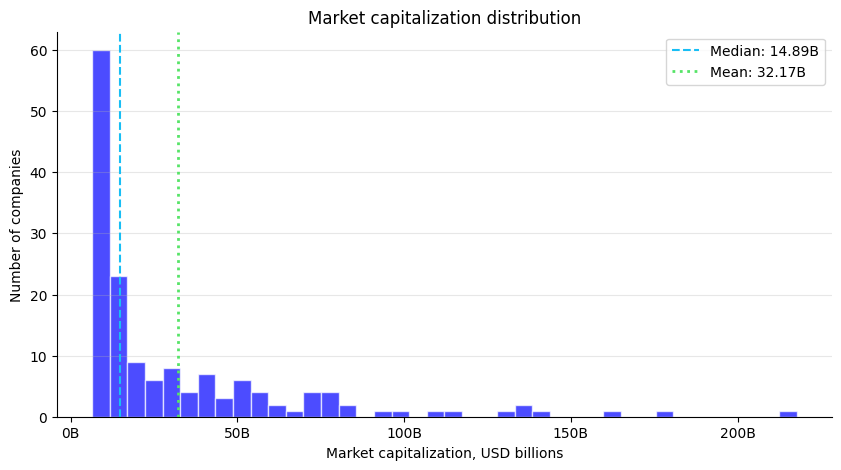

In [709]:
market_cap = df_filtered["market_cap_b"].dropna()


fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    market_cap,          # Data to plot: one numerical value per company.
                         # In this case, market_cap contains the market capitalization values.

    bins=40,             # Number of intervals used to split the data.
                         # More bins = more detail, but the chart may become noisy.
                         # Fewer bins = smoother chart, but less detail.

    color="blue",     # Fill color of the bars.
                         # Hexadecimal color code.
                         # This blue is visually clean and works well in business charts.

    edgecolor="white",   # Color of the border around each bar.
                         # White edges help separate adjacent bars visually.

    alpha=0.70           # Transparency level of the bars.
                         # 1.0 means fully opaque.
                         # 0.0 means fully transparent.
                         # 0.70 keeps the color strong but slightly softer.
)

median_value = market_cap.median()
mean_value = market_cap.mean()

ax.axvline(median_value, color="#18BEF5", linestyle="--", linewidth=1.5, label=f"Median: {median_value:,.2f}B")
ax.axvline(mean_value, color="#56E467", linestyle=":", linewidth=2, label=f"Mean: {mean_value:,.2f}B")

ax.set_title("Market capitalization distribution")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.30)
ax.legend()
clean_spines(ax)

plt.show()





## Step 2: Outlier Direction 
Plot a boxplot of market_cap. If needed remove outliers. Use the cleaned dataset from this point forward.

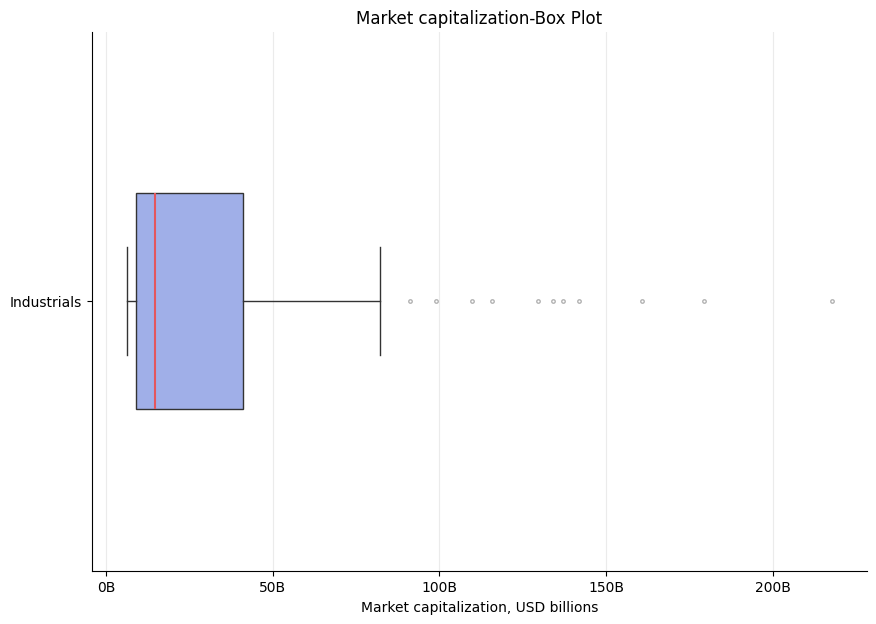

In [710]:

market_cap = df_filtered["market_cap_b"].dropna()

fig, ax = plt.subplots(figsize=(10, 7))

ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    market_cap,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    tick_labels = ['Industrials'],
    widths=0.4, 

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#A0AFE8", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E4565D", "linewidth":1.5},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},

    # Style of the outlier points:
    # - marker="o" uses circular markers;
    # - markersize=3 keeps them small;
    # - alpha=0.35 makes them semi-transparent.
    flierprops={"marker": "o", "markersize":2.5, "alpha": 0.30}
)


ax.set_title("Market capitalization-Box Plot")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()



the lower bound is: -39
the upper bound is: 89


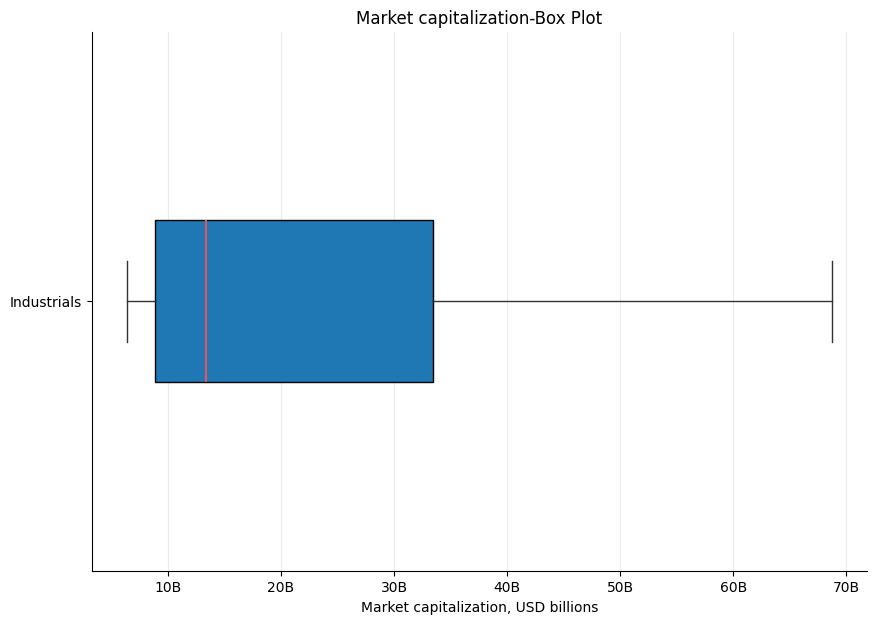

In [711]:
Q1 = df_filtered["market_cap_b"].quantile(0.25)
Q3 = df_filtered["market_cap_b"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

df_clean = df_filtered[(df_filtered["market_cap_b"] >= lower)&
                      (df_filtered["market_cap_b"]<= upper)
                        ]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(
    df_clean["market_cap_b"].dropna(),
    vert=False,
    patch_artist=True,
    tick_labels=["Industrials"],
    widths=0.3,
    medianprops={"color": "#E4565D", "linewidth":1.5},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    showfliers=False
   
)

ax.set_title("Market capitalization-Box Plot")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()



## Step 3: Industry comparison: Four metrics 
Create a single figure with 4 subplots: Each subplot is a horizontal bar chart showing the mean value per industry for one of the following metrics:
+  market_cap 
+  total_revenue 
+ profit_margins 
+  beta 


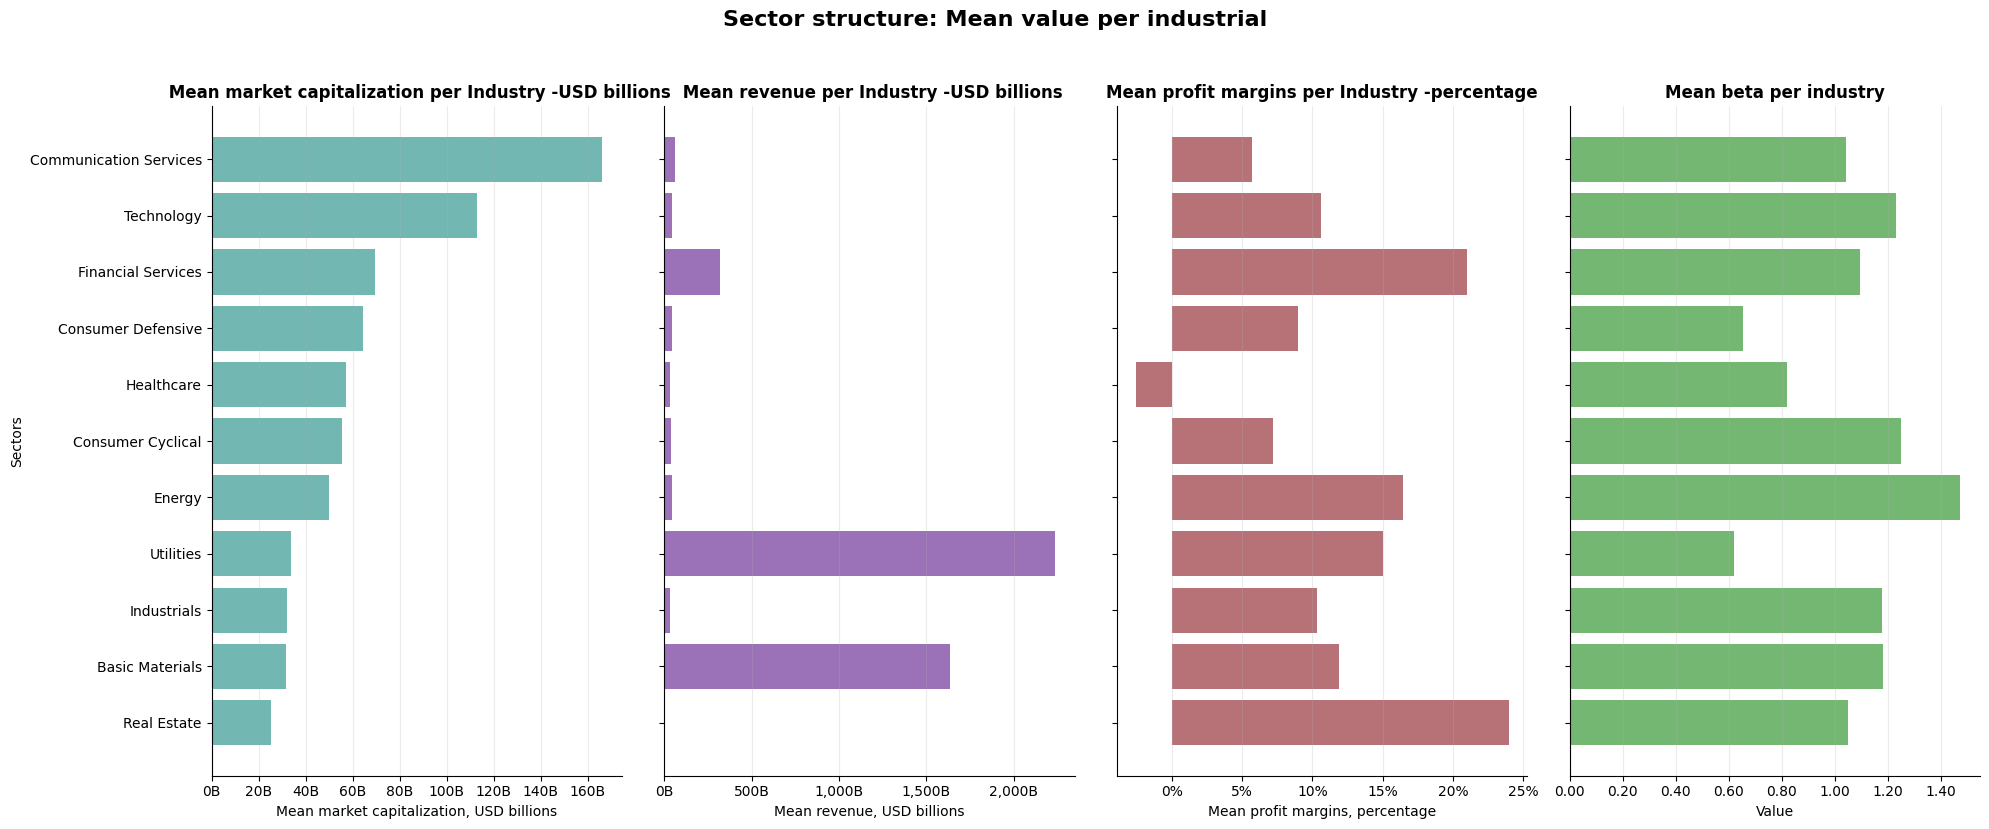

In [712]:
df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["profit_margins_pct"] = df["profit_margins"] * 100

grouped = df[["sector", "market_cap_b", "revenue_b", "profit_margins_pct", "beta"]].groupby("sector").mean()

grouped = grouped.sort_values("market_cap_b", ascending=True)

# Create one figure with four columns.
fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 8),
    sharey=True
)

ax_cap = ax[0]
ax_rev = ax[1]
ax_prof = ax[2]
ax_beta = ax[3]



# 1. Market Cap
ax_cap.barh(
    grouped.index,
    grouped["market_cap_b"],
    color="#72B7B2"
)

ax_cap.set_title(" Mean market capitalization per Industry -USD billions",fontweight="bold")
ax_cap.set_xlabel("Mean market capitalization, USD billions")
ax_cap.set_ylabel("Sectors")
ax_cap.grid(axis="x", alpha=0.25)
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax_cap)

# 2. Revenue
ax_rev.barh(
    grouped.index,
    grouped["revenue_b"],
    color = "#9B72B7"
)

ax_rev.set_title(" Mean revenue per Industry -USD billions",fontweight="bold")
ax_rev.set_xlabel("Mean revenue, USD billions")
ax_rev.grid(axis="x", alpha=0.25)
ax_rev.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax_rev)

# 3. Profit Margins
ax_prof.barh(grouped.index,
            grouped["profit_margins_pct"],
            color ="#B77278"
)
ax_prof.set_title("Mean profit margins per Industry -percentage",fontweight="bold")
ax_prof.set_xlabel("Mean profit margins, percentage")
ax_prof.grid(axis="x", alpha=0.25)
ax_prof.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_prof)

# 4. Beta
ax_beta.barh(
    grouped.index,
    grouped["beta"],
    color ="#74B772"
)

ax_beta.set_title("Mean beta per industry",fontweight="bold")
ax_beta.set_xlabel("Value")
ax_beta.grid(axis="x", alpha=0.25)
ax_beta.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))
clean_spines(ax_beta)

fig.suptitle(
    "Sector structure: Mean value per industrial",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()
 

## Step 4: Industry dispersion
Create 4 boxplots, one per metric(market_cap,total_revenue,profit_margins,beta). Each boxplot must show the full distribution broken down per industry, not just the mean. 

the lower bound is: -44
the upper bound is: 101


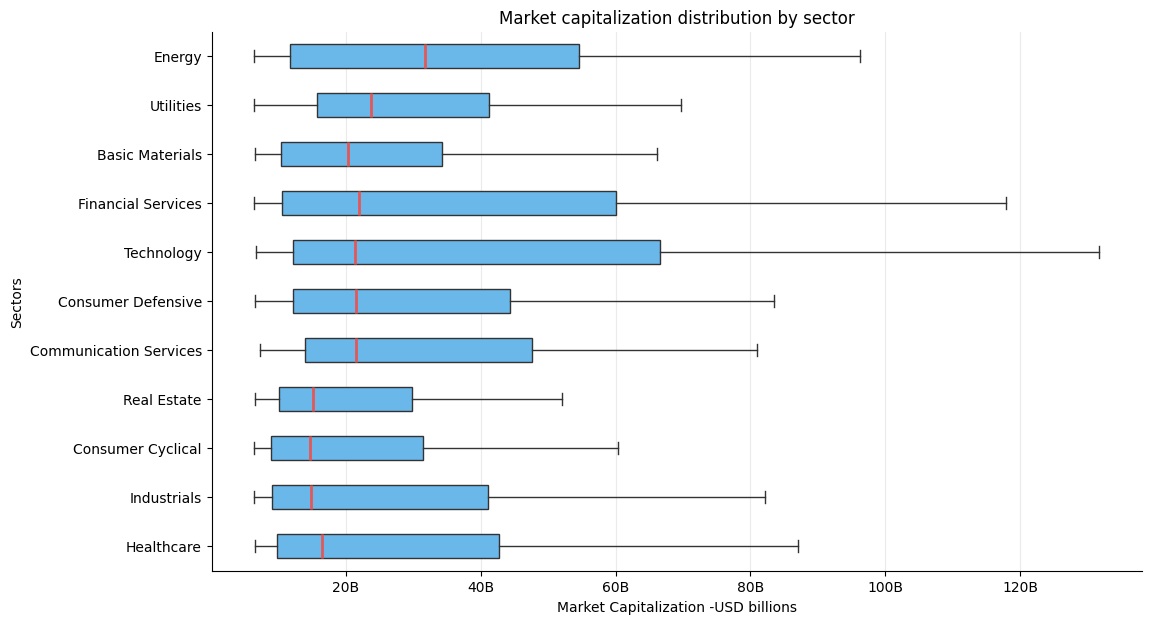

In [713]:
Q1 = df["market_cap_b"].quantile(0.25)
Q3 = df["market_cap_b"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

df_clean_1 = df[(df["market_cap_b"] >= lower)&
                      (df["market_cap_b"]<= upper)                    
].dropna(subset=["sector", "market_cap_b"]).copy()

# Order sectors by median profitability.
sector_order = (
    df_clean_1.groupby("sector")["market_cap_b"]
    .median()
    .sort_values(ascending=True)
    .index
)

# Build the input data for the box plot.
# Matplotlib expects a list of numeric arrays, where each array contains
# the profit margin values for one sector.
# box_data = [ [12.5, 18.0, 21.3, 9.7],      # Technology ...]
# The order follows sector_order, so boxes and labels stay aligned.
box_data = [
    box_df.loc[box_df["sector"] == sector, "market_cap_b"].values
    for sector in sector_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# Each box summarizes the distribution of profit margins within one sector.
ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    box_data,

    # Labels shown next to each box.
    # The order must match the order of box_data.
    # In Matplotlib 3.9+, this parameter is called tick_labels.
    tick_labels=sector_order,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#6AB7EA", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E45756", "linewidth": 2},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},
    showfliers=False

    
)


ax.set_title("Market capitalization distribution by sector")
ax.set_xlabel("Market Capitalization -USD billions")
ax.set_ylabel("Sectors")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

the lower bound is: -23
the upper bound is: 47


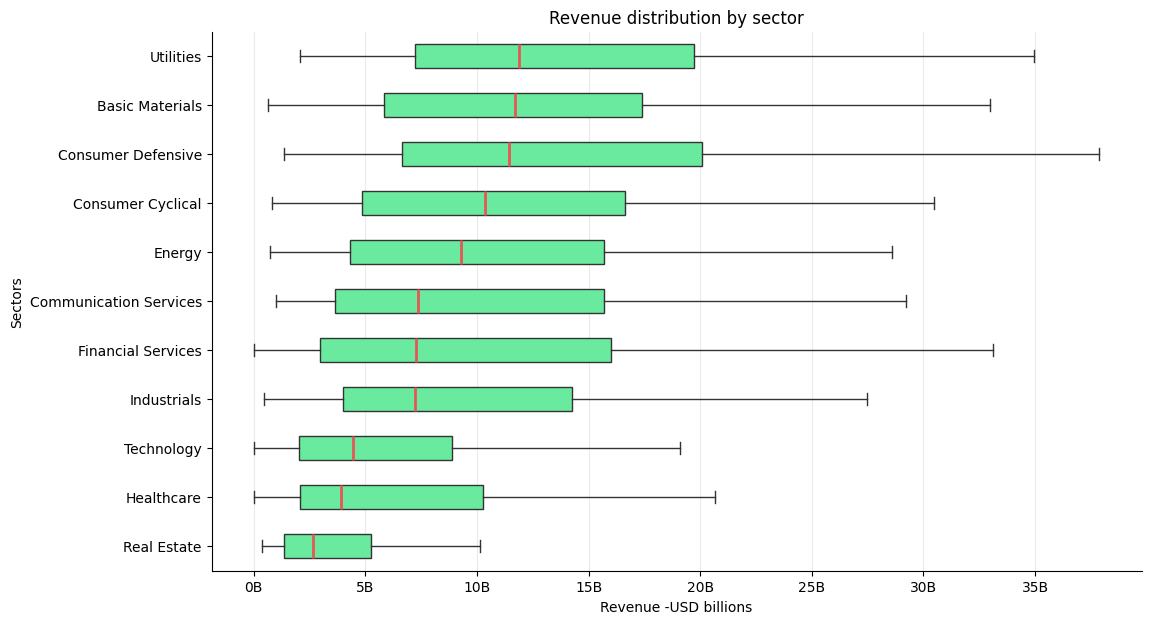

In [714]:
Q1 = df["revenue_b"].quantile(0.25)
Q3 = df["revenue_b"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

df_clean_2 = df[(df["revenue_b"] >= lower)&
                      (df["revenue_b"]<= upper)                    
].dropna(subset=["sector", "revenue_b"]).copy()




# Order sectors by median profitability.
sector_order = (
    df_clean_2.groupby("sector")["revenue_b"]
    .median()
    .sort_values(ascending=True)
    .index
)

# Build the input data for the box plot.
# Matplotlib expects a list of numeric arrays, where each array contains
# the profit margin values for one sector.
# box_data = [ [12.5, 18.0, 21.3, 9.7],      # Technology ...]
# The order follows sector_order, so boxes and labels stay aligned.
box_data = [
    df_clean_2.loc[df_clean_2["sector"] == sector, "revenue_b"].values
    for sector in sector_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# Each box summarizes the distribution of profit margins within one sector.
ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    box_data,

    # Labels shown next to each box.
    # The order must match the order of box_data.
    # In Matplotlib 3.9+, this parameter is called tick_labels.
    tick_labels=sector_order,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#6AEA9F", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E45756", "linewidth": 2},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},

    # Style of the outlier points:
    # - marker="o" uses circular markers;
    # - markersize=3 keeps them small;
    # - alpha=0.35 makes them semi-transparent.
    showfliers=False
)


ax.set_title("Revenue distribution by sector")
ax.set_xlabel("Revenue -USD billions")
ax.set_ylabel("Sectors")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

the lower bound is: -18
the upper bound is: 44


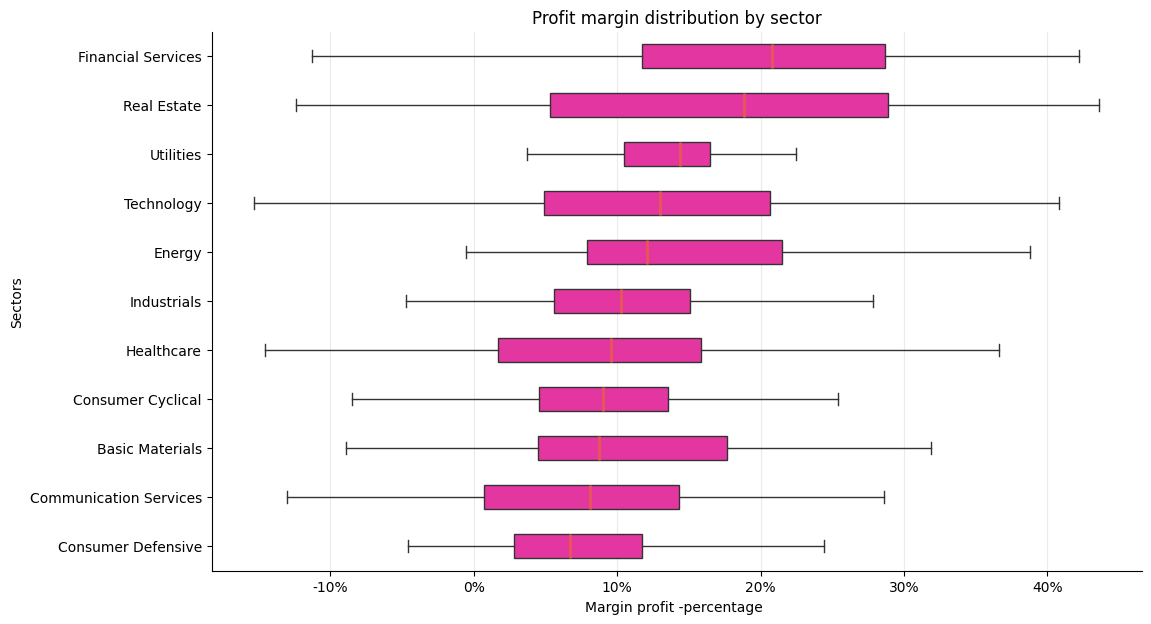

In [715]:
Q1 = df["profit_margin_pct"].quantile(0.25)
Q3 = df["profit_margin_pct"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

df_clean_3 = df[(df["profit_margin_pct"] >= lower)&
                (df["profit_margin_pct"]<= upper)
            ].dropna(subset=["sector", "profit_margin_pct"]).copy()



# Order sectors by median profitability.
sector_order = (
    df_clean_3.groupby("sector")["profit_margin_pct"]
    .median()
    .sort_values(ascending=True)
    .index
)

# Build the input data for the box plot.
# Matplotlib expects a list of numeric arrays, where each array contains
# the profit margin values for one sector.
# box_data = [ [12.5, 18.0, 21.3, 9.7],      # Technology ...]
# The order follows sector_order, so boxes and labels stay aligned.
box_data = [
    df_clean_3.loc[df_clean_3["sector"] == sector, "profit_margin_pct"].values
    for sector in sector_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# Each box summarizes the distribution of profit margins within one sector.
ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    box_data,

    # Labels shown next to each box.
    # The order must match the order of box_data.
    # In Matplotlib 3.9+, this parameter is called tick_labels.
    tick_labels=sector_order,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#E436A1", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E45756", "linewidth": 2},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},

    # Style of the outlier points:
    # - marker="o" uses circular markers;
    # - markersize=3 keeps them small;
    # - alpha=0.35 makes them semi-transparent.
    showfliers=False
)


ax.set_title("Profit margin distribution by sector")
ax.set_xlabel("Margin profit -percentage ")
ax.set_ylabel("Sectors")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

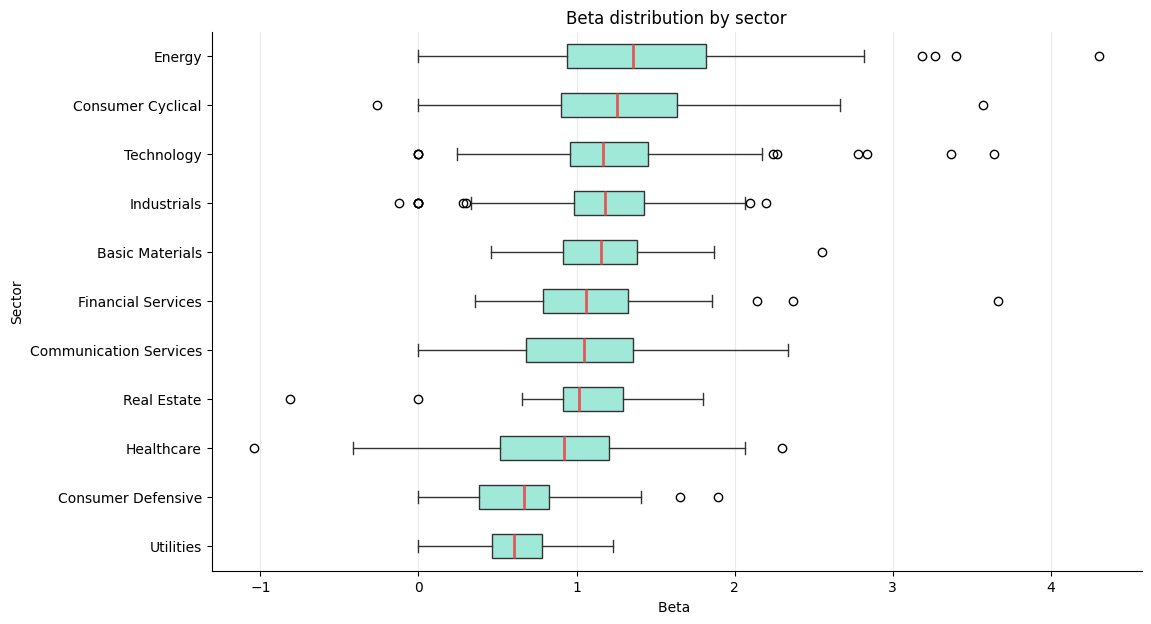

In [716]:
# Order sectors by median profitability.

box_df = df.dropna(subset=["sector", "beta"]).copy()
sector_order = (
    box_df.groupby("sector")["beta"]
    .median()
    .sort_values(ascending=True)
    .index
)

# Build the input data for the box plot.
# Matplotlib expects a list of numeric arrays, where each array contains
# the profit margin values for one sector.
# box_data = [ [12.5, 18.0, 21.3, 9.7],      # Technology ...]
# The order follows sector_order, so boxes and labels stay aligned.
box_data = [
    df_clean_1.loc[df_clean_1["sector"] == sector, "beta"].values
    for sector in sector_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# Each box summarizes the distribution of profit margins within one sector.
ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    box_data,

    # Labels shown next to each box.
    # The order must match the order of box_data.
    # In Matplotlib 3.9+, this parameter is called tick_labels.
    tick_labels=sector_order,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#A0E8D7", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E45756", "linewidth": 2},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},

    # Style of the outlier points:
    # - marker="o" uses circular markers;
    # - markersize=3 keeps them small;
    # - alpha=0.35 makes them semi-transparent.
    
)


ax.set_title("Beta distribution by sector")
ax.set_xlabel("Beta ")
ax.set_ylabel("Sector")
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()